In [1]:
!pip install split-folders
!pip install torch-summary

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='darkgrid')
import copy 
import os 
import torch
from PIL import Image 
from torch.utils.data import Dataset
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau 
import torch.nn as nn 
from torchvision import utils 
from torchvision.datasets import ImageFolder
import splitfolders
from torchsummary import summary
import torch.nn.functional as F
import pathlib
from sklearn.metrics import confusion_matrix, classification_report
import itertools 
from tqdm.notebook import trange, tqdm
from torch import optim
import warnings
warnings.filterwarnings('ignore')

In [3]:
from IPython.core.display import display, HTML, Javascript

color_map = ['#FFFFFF','#FF5733']

prompt = color_map[-1]
main_color = color_map[0]
strong_main_color = color_map[1]
custom_colors = [strong_main_color, main_color]

css_file = '''
div #notebook {
background-color: white;
line-height: 20px;
}

#notebook-container {
%s
margin-top: 2em;
padding-top: 2em;
border-top: 4px solid %s;
-webkit-box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
    box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
}

div .input {
margin-bottom: 1em;
}

.rendered_html h1, .rendered_html h2, .rendered_html h3, .rendered_html h4, .rendered_html h5, .rendered_html h6 {
color: %s;
font-weight: 600;
}

div.input_area {
border: none;
    background-color: %s;
    border-top: 2px solid %s;
}

div.input_prompt {
color: %s;
}

div.output_prompt {
color: %s; 
}

div.cell.selected:before, div.cell.selected.jupyter-soft-selected:before {
background: %s;
}

div.cell.selected, div.cell.selected.jupyter-soft-selected {
    border-color: %s;
}

.edit_mode div.cell.selected:before {
background: %s;
}

.edit_mode div.cell.selected {
border-color: %s;

}
'''

def to_rgb(h): 
    return tuple(int(h[i:i+2], 16) for i in [0, 2, 4])

main_color_rgba = 'rgba(%s, %s, %s, 0.1)' % (to_rgb(main_color[1:]))
open('notebook.css', 'w').write(css_file % ('width: 95%;', main_color, main_color, main_color_rgba, 
                                            main_color,  main_color, prompt, main_color, main_color, 
                                            main_color, main_color))

def nb(): 
    return HTML("<style>" + open("notebook.css", "r").read() + "</style>")
nb()


![](https://assets.neurosurgicalatlas.com/aaroncohen-gadol-com/patients/brain-tumor-fig1.jpg)

In [4]:
labels_df = pd.read_csv('/kaggle/input/datasets/preetviradiya/brian-tumor-dataset/metadata.csv')
print(labels_df.head().to_markdown())

|    |   Unnamed: 0 | image           | class   | format   | mode   | shape         |
|---:|-------------:|:----------------|:--------|:---------|:-------|:--------------|
|  0 |            0 | Cancer (1).jpg  | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  1 |            1 | Cancer (1).png  | tumor   | PNG      | L      | (300, 240)    |
|  2 |            2 | Cancer (1).tif  | tumor   | TIFF     | RGB    | (256, 256, 3) |
|  3 |            3 | Cancer (10).jpg | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  4 |            4 | Cancer (10).tif | tumor   | TIFF     | RGB    | (256, 256, 3) |


In [5]:
os.listdir('/kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set')

['Brain Tumor Data Set']

In [6]:
labels_df.shape

(4600, 6)

In [7]:
import os
import shutil
import random
from pathlib import Path

# Define paths
source_dir = Path('/kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set')
output_dir = Path('/kaggle/working/brain')

# Define labels based on subfolders
classes = [d.name for d in source_dir.iterdir() if d.is_dir()]

for cls in classes:
    files = list((source_dir / cls).glob('*.jpg')) # Change extension if needed
    random.shuffle(files)
    
    # Calculate split index
    train_idx = int(len(files) * 0.8)
    train_files = files[:train_idx]
    val_files = files[train_idx:]
    
    # Create directories
    (output_dir / 'train' / cls).mkdir(parents=True, exist_ok=True)
    (output_dir / 'val' / cls).mkdir(parents=True, exist_ok=True)
    
    # Copy files
    for f in train_files:
        shutil.copy(f, output_dir / 'train' / cls / f.name)
    for f in val_files:
        shutil.copy(f, output_dir / 'val' / cls / f.name)

print("Dataset split completed successfully.")

Dataset split completed successfully.


In [8]:
# define transformation
transform = transforms.Compose(
    [
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
   ]
)

In [9]:
import shutil
from pathlib import Path

# Path where your files currently are
source = Path('/kaggle/working/brain/train/Brain Tumor Data Set')
# Path where they should be for ImageFolder
target = Path('/kaggle/working/brain/train')

# Move 'Brain Tumor' and 'Healthy' folders up one level
for class_folder in source.iterdir():
    if class_folder.is_dir():
        shutil.move(str(class_folder), str(target / class_folder.name))

# Repeat for validation set
source_val = Path('/kaggle/working/brain/val/Brain Tumor Data Set')
target_val = Path('/kaggle/working/brain/val')
for class_folder in source_val.iterdir():
    if class_folder.is_dir():
        shutil.move(str(class_folder), str(target_val / class_folder.name))

In [10]:
import os
from pathlib import Path

# Start from the root output
base_path = Path('/kaggle/working/brain/train')

# Recursively look for any subdirectories that contain images
def find_image_folders(path):
    for entry in path.rglob('*'):
        if entry.is_dir():
            # Check if this directory contains images
            images = list(entry.glob('*.jpg')) + list(entry.glob('*.png'))
            if images:
                print(f"Found images in: {entry}")

find_image_folders(base_path)

In [11]:
import os
from pathlib import Path

# Search from the base of your output directory
search_path = Path('/kaggle/working/brain')

# Find the directory that contains the subfolders 'Brain Tumor' and 'Healthy'
for path in search_path.rglob('Brain Tumor'):
    # The parent of the 'Brain Tumor' folder is the correct root for ImageFolder
    correct_path = path.parent
    print(f"Found class folders at: {correct_path}")

In [12]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files[:2]: # Show first 2 files only
            print(f'{subindent}{f}')
        if len(files) > 2:
            print(f'{subindent}...')

list_files('/kaggle/working/brain')

brain/
    train/
        Brain Tumor Data Set/
    val/
        Brain Tumor Data Set/


In [13]:
import os
for root, dirs, files in os.walk('/kaggle/working/brain'):
    print(f"Root: {root}, Dirs: {dirs}")

Root: /kaggle/working/brain, Dirs: ['train', 'val']
Root: /kaggle/working/brain/train, Dirs: ['Brain Tumor Data Set']
Root: /kaggle/working/brain/train/Brain Tumor Data Set, Dirs: []
Root: /kaggle/working/brain/val, Dirs: ['Brain Tumor Data Set']
Root: /kaggle/working/brain/val/Brain Tumor Data Set, Dirs: []


In [14]:
import os

source_base = '/kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set'

# Find the directory that actually contains image files
for root, dirs, files in os.walk(source_base):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            print(f"Found images in: {root}")
            break # Found the path, no need to keep searching

Found images in: /kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor
Found images in: /kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set/Healthy


In [15]:
import splitfolders

# The exact path where your images reside
correct_source_path = '/kaggle/input/datasets/preetviradiya/brian-tumor-dataset/Brain Tumor Data Set/Brain Tumor Data Set'

# Re-run the split
splitfolders.ratio(correct_source_path, output='/kaggle/working/brain_split', 
                   seed=20, ratio=(0.8, 0.2), group_prefix=None)

Copying files: 4600 files [01:13, 62.44 files/s] 


In [16]:
import os

def find_subdirs(path):
    print(f"Checking: {path}")
    for root, dirs, files in os.walk(path):
        print(f"  Found sub-directories: {dirs}")
        # Stop after looking at the first level
        break

find_subdirs('/kaggle/working/brain_split/train')

Checking: /kaggle/working/brain_split/train
  Found sub-directories: ['Healthy', 'Brain Tumor']


In [17]:
import shutil
from pathlib import Path
import torchvision

# 1. Remove the empty/redundant folder causing the error
redundant_folder = Path('/kaggle/working/brain_split/train/Brain Tumor Data Set')
if redundant_folder.exists():
    shutil.rmtree(redundant_folder)

redundant_val_folder = Path('/kaggle/working/brain_split/val/Brain Tumor Data Set')
if redundant_val_folder.exists():
    shutil.rmtree(redundant_val_folder)

# 2. Now load using the parent directory
# ImageFolder will now only see 'Brain Tumor' and 'Healthy'
train_set = torchvision.datasets.ImageFolder(root='/kaggle/working/brain_split/train', transform=transform)
val_set = torchvision.datasets.ImageFolder(root='/kaggle/working/brain_split/val', transform=transform)

print(f"Success! Loaded {len(train_set)} training images.")
print(f"Classes found: {train_set.class_to_idx}")

Success! Loaded 3679 training images.
Classes found: {'Brain Tumor': 0, 'Healthy': 1}


In [18]:
import os
import torch
import torchvision
from torchvision import transforms
from pathlib import Path

# Set up transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Find the path containing 'Brain Tumor' and 'Healthy' folders
base_path = Path('/kaggle/working/brain')
train_root = None
val_root = None

for path in base_path.rglob('Brain Tumor'):
    parent = path.parent
    if 'train' in str(parent):
        train_root = parent
    elif 'val' in str(parent):
        val_root = parent

# Initialize datasets
# You have already confirmed these paths exist and work:
train_root = '/kaggle/working/brain_split/train'
val_root = '/kaggle/working/brain_split/val'

# Initialize datasets directly
train_set = torchvision.datasets.ImageFolder(root=train_root, transform=transform)
val_set = torchvision.datasets.ImageFolder(root=val_root, transform=transform)

print(f"Success! Loaded {len(train_set)} training images and {len(val_set)} validation images.")

Success! Loaded 3679 training images and 921 validation images.


In [19]:
import torch

batch_size = 64

# Assuming train_set and val_set are already defined from your last successful step
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [20]:
# Print shape for Training data and Validation data
for key, value in {'Training data': train_loader, "Validation data": val_loader}.items():
    for X, y in value:
        print(f"{key}:")
        print(f"Shape of X : {X.shape}") # Should be [64, 3, 128, 128]
        print(f"Shape of y: {y.shape} {y.dtype}\n") # Should be [64] torch.int64
        break

Training data:
Shape of X : torch.Size([64, 3, 128, 128])
Shape of y: torch.Size([64]) torch.int64

Validation data:
Shape of X : torch.Size([64, 3, 128, 128])
Shape of y: torch.Size([64]) torch.int64



In [21]:
'''This function can be useful in determining the output size of a convolutional layer in a neural network,
given the input dimensions and the convolutional layer's parameters.'''

def findConv2dOutShape(hin,win,conv,pool=2):
    # get conv arguments
    kernel_size = conv.kernel_size
    stride=conv.stride
    padding=conv.padding
    dilation=conv.dilation

    hout=np.floor((hin+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
    wout=np.floor((win+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)

    if pool:
        hout/=pool
        wout/=pool
    return int(hout),int(wout)

In [22]:
class CNN_TUMOR(nn.Module):
    def __init__(self, params):
        super(CNN_TUMOR, self).__init__()
        
        Cin, Hin, Win = params["shape_in"]
        init_f = params["initial_filters"] 
        # Store these as instance attributes so they are accessible later
        self.num_fc1 = params["num_fc1"]  
        num_classes = params["num_classes"] 
        self.dropout_rate = params["dropout_rate"] 
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(Cin, init_f, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(init_f, 2*init_f, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(2*init_f, 4*init_f, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(4*init_f, 8*init_f, kernel_size=3, padding=1)
        
        # Use the value we debugged
        self.num_flatten = 4096 
        
        # Initialize linear layers using self.num_fc1
        self.fc1 = nn.Linear(self.num_flatten, self.num_fc1)
        self.fc2 = nn.Linear(self.num_fc1, num_classes)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv4(X))
        X = F.max_pool2d(X, 2, 2)
        
        X = X.view(X.size(0), -1) 
        X = F.relu(self.fc1(X))
        X = F.dropout(X, self.dropout_rate, training=self.training)
        X = self.fc2(X)
        return F.log_softmax(X, dim=1)

In [23]:
params_model={
        "shape_in": (3,256,256), 
        "initial_filters": 8,    
        "num_fc1": 100,
        "dropout_rate": 0.25,
        "num_classes": 2}

# Create instantiation of Network class
cnn_model = CNN_TUMOR(params_model)

# define computation hardware approach (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = cnn_model.to(device)

In [24]:
# Model Summary for CNN Model
summary(cnn_model, input_size=(3, 256, 256),device=device.type)

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            224
├─Conv2d: 1-2                            1,168
├─Conv2d: 1-3                            4,640
├─Conv2d: 1-4                            18,496
├─Linear: 1-5                            409,700
├─Linear: 1-6                            202
Total params: 434,430
Trainable params: 434,430
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            224
├─Conv2d: 1-2                            1,168
├─Conv2d: 1-3                            4,640
├─Conv2d: 1-4                            18,496
├─Linear: 1-5                            409,700
├─Linear: 1-6                            202
Total params: 434,430
Trainable params: 434,430
Non-trainable params: 0

In [25]:
loss_func = nn.NLLLoss(reduction="sum")

In [26]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
opt = optim.Adam(cnn_model.parameters(), lr=3e-4)
lr_scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=20)

In [27]:
# Function to get the learning rate
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']

# Function to compute the loss value per batch of data
def loss_batch(loss_func, output, target, opt=None):
    
    loss = loss_func(output, target) # get loss
    pred = output.argmax(dim=1, keepdim=True) # Get Output Class
    metric_b=pred.eq(target.view_as(pred)).sum().item() # get performance metric
    
    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()

    return loss.item(), metric_b

# Compute the loss value & performance metric for the entire dataset (epoch)
def loss_epoch(model,loss_func,dataset_dl,opt=None):
    
    run_loss=0.0 
    t_metric=0.0
    len_data=len(dataset_dl.dataset)

    # internal loop over dataset
    for xb, yb in dataset_dl:
        # move batch to device
        xb=xb.to(device)
        yb=yb.to(device)
        output=model(xb) # get model output
        loss_b,metric_b=loss_batch(loss_func, output, yb, opt) # get loss per batch
        run_loss+=loss_b        # update running loss

        if metric_b is not None: # update running metric
            t_metric+=metric_b    
    
    loss=run_loss/float(len_data)  # average loss value
    metric=t_metric/float(len_data) # average metric value
    
    return loss, metric

In [28]:
import copy
import torch
from tqdm import tqdm

def Train_Val(model, params, verbose=False):
    # Get parameters
    epochs = params["epochs"]
    loss_func = params["f_loss"]
    opt = params["optimiser"]
    train_dl = params["train"]
    val_dl = params["val"]
    lr_scheduler = params["lr_change"]
    weight_path = params["weight_path"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    loss_history = {"train": [], "val": []} 
    metric_history = {"train": [], "val": []} 
    
    best_model_wts = copy.deepcopy(model.state_dict()) 
    best_loss = float('inf') 

    for epoch in tqdm(range(epochs)):
        current_lr = get_lr(opt)
        if verbose:
            print(f'Epoch {epoch}/{epochs - 1}, current lr={current_lr:.6f}')
        
        # Training
        model.train()
        train_loss, train_metric = loss_epoch(model, loss_func, train_dl, opt)
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)

        # Validation
        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model, loss_func, val_dl)
        
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)
        
        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), weight_path)
            if verbose:
                print("Copied best model weights!")
        
        # LR Scheduler
        lr_scheduler.step(val_loss)
        if current_lr != get_lr(opt):
            if verbose:
                print("Learning rate changed! Loading best model weights.")
            model.load_state_dict(best_model_wts) 

        if verbose:
            print(f"train loss: {train_loss:.6f}, val loss: {val_loss:.6f}, accuracy: {100*val_metric:.2f}%")
            print("-" * 10)

    model.load_state_dict(best_model_wts)
    return model, loss_history, metric_history

In [29]:
import torch.nn as nn
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Define the optimizer separately
optimizer = optim.Adam(cnn_model.parameters(), lr=3e-4)

# 2. Define the scheduler using the optimizer variable
lr_scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=20
)

# 3. Use these in your dictionary
params_train = {
    "train": train_loader,
    "val": val_loader,
    "epochs": 60,
    "optimiser": optimizer,
    "lr_change": lr_scheduler,
    "f_loss": nn.NLLLoss(reduction="sum"),
    "weight_path": "weights.pt",
}

# train and validate the model
cnn_model, loss_hist, metric_hist = Train_Val(cnn_model, params_train)

100%|██████████| 60/60 [06:55<00:00,  6.93s/it]


<Axes: >

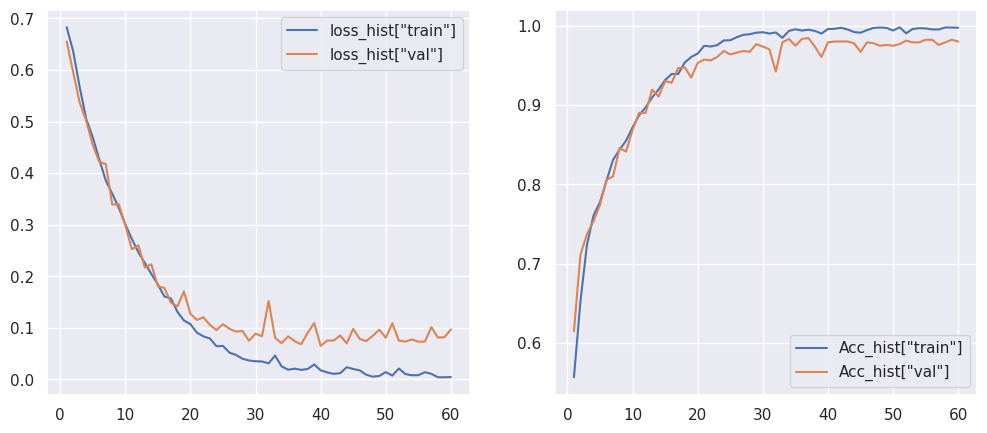

In [30]:
# Convergence History Plot
epochs=params_train["epochs"]
fig,ax = plt.subplots(1,2,figsize=(12,5))

sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["train"],ax=ax[0],label='loss_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["val"],ax=ax[0],label='loss_hist["val"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["train"],ax=ax[1],label='Acc_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["val"],ax=ax[1],label='Acc_hist["val"]')

In [31]:
# define function For Classification Report
def Ture_and_Pred(val_loader, model):
    i = 0
    y_true = []
    y_pred = []
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.numpy()
        outputs = model(images)
        _, pred = torch.max(outputs.data, 1)
        pred = pred.detach().cpu().numpy()
        
        y_true = np.append(y_true, labels)
        y_pred = np.append(y_pred, pred)
    
    return y_true, y_pred


# check confusion matrix for error analysis
y_true, y_pred = Ture_and_Pred(val_loader, cnn_model)

print(classification_report(y_true, y_pred), '\n\n')
cm = confusion_matrix(y_true, y_pred)

              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       503
         1.0       0.97      0.99      0.98       418

    accuracy                           0.98       921
   macro avg       0.98      0.98      0.98       921
weighted avg       0.98      0.98      0.98       921
 




In [32]:
CLA_label = {v: k for k, v in train_set.class_to_idx.items()}

print("Labels defined:", CLA_label)

Labels defined: {0: 'Brain Tumor', 1: 'Healthy'}


In [33]:
from sklearn.metrics import confusion_matrix
import torch

# Put model in eval mode
cnn_model.eval()

y_true = []
y_pred = []

# Collect predictions from your validation loader
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        output = cnn_model(xb)
        pred = torch.argmax(output, dim=1)
        
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

# Calculate the matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix calculated successfully.")

Confusion Matrix calculated successfully.


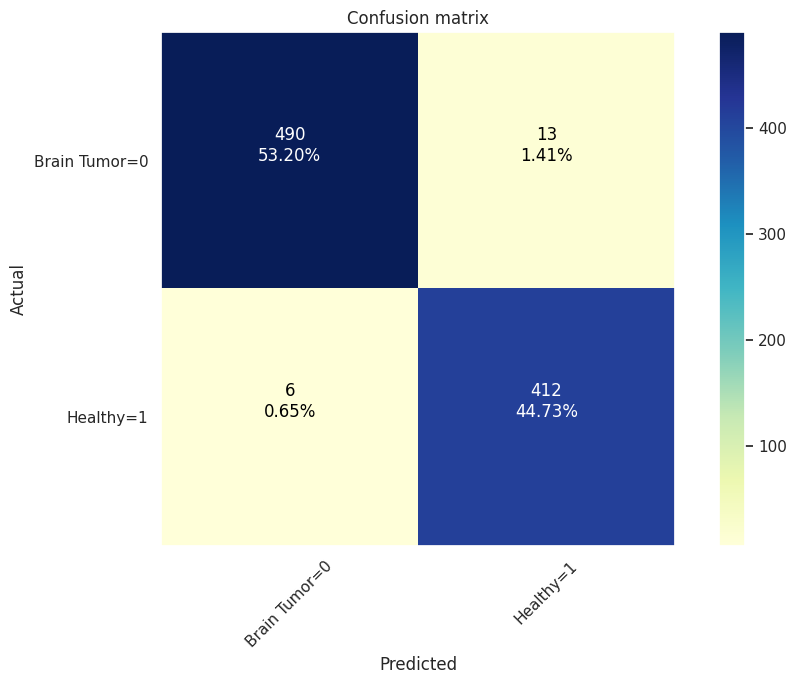

In [34]:
# Confusion Matrix Plotting Function
def show_confusion_matrix(cm, CLA_label, title='Confusion matrix', cmap=plt.cm.YlGnBu):
    
    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(CLA_label))
    

    plt.xticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()], rotation=45)
    plt.yticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()])

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i,j]}\n{cm[i,j]/np.sum(cm)*100:.2f}%", horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

show_confusion_matrix(cm, CLA_label)

In [35]:
torch.save(cnn_model, "Brain_Tumor_model.pt")